# Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Чтение из файла

In [20]:
df = pd.read_csv('../dataset/texts_from_avito.csv', sep=';')
df = df[df['тема'].notna()]
df = df[['тема', 'текст']]
# df = df[df['тема'] != "не вопрос клиента"]
df

,тема,текст
0,шуруповерт,"добрый вечер! подскажите, у вас можно взять в ..."
1,пылесос,Здравствуйте) сколько стоит аренда строительно...
2,плиткорез ручной,Доброе утро. Подскажите пожалуйста в какую цен...
3,фен,Доброе утро Есть строительный фен на аккумулят...
4,не вопрос клиента,Добрый день
...,...,...
911,дрель для алмазного бурения,"Добрый утро, есть дрель для сухого алмазного ..."
912,штроборез,"Здравствуйте, хотел бы взять у вас в прокат ш..."
913,не вопрос клиента,Здравствуйте
914,домкрат бутылочный,Здравствуйте! Какие домкраты есть в аренду с ...


In [22]:
df_small = df[df['тема']=='шуруповерт']
examples = df_small['текст'].tolist()
examples

['добрый вечер! подскажите, у вас можно взять в аренду шурповерт?',
 'Здравствуйте, сколько будет стоить арендовать, шуроповёрт на одни сутки',
 'Здравствуйте, меня зовут Александр, просили написать на Авито на прямую по поводу аренды шуруповерта и перфоратора.',
 'Здравствуйте! Нужен шуруповерт, завтра в районе 12',
 'Здравствуйте, мне нужно шуруповерт. На 3 дня. Какие условия?',
 'Здравствуйте! Сколько будет стоить аренда шуруповерта?',
 'Здравствуйте! Хотел бы уточнить стоимость аренды шуруповерта на 1 день',
 'здравствуйте есть шуруповерт ленточный ?',
 'Здравствуйте, подскажите пожалуйста, нам нужен в аренду шуроповерт и шестигранный ключ ( но только больше универсального, для разбора дивана). Сколько это будет стоить по цене, если арендовать его у вас на сутки, с 18:00',
 'Здравствуйте, сколько будет стоит шуруповерт?',
 'Здравствуйте  Аренда шуруповерта какая стоимость? Залог?',
 'Добрый вечер! Мне нужны инструменты: шуруповёрт. У вас есть такое, если да, то сколько это будет ст

Тексты запросов содержат много "паразитных" слов, не имеющих прямого отношения к теме запроса.
Стоит удалить их на этапе предобработки.

## Предобработка

In [6]:
def clear_text(text: str) -> str:
    # функция очистки текстов от паразитных слов, не относящихся к теме запроса
    
    trash_values = [
        'добрый вечер', 
        'добрый день', 
        'доброе утро',
        'добрый утро',
        'здравствуйте',
        'подскажите',
        'пожалуйста',
        'хотелось',
        'интересует',
        'нужен',
        'нужно',
        'хочу',
        'надо',
        'можно',
        'аренда',
        'аренду',
        'хочу',
        'хотел бы',
        'в наличии',
        'сколько стоит',
    ]
    text = text.lower()
    for value in trash_values:
        text = text.replace(value, '')
    return text

In [7]:
# очистка текстов от паразитных слов

df['текст'] = df['текст'].map(clear_text)
df = df[df['текст'] != '']
df

,тема,текст
0,шуруповерт,"! , у вас взять в шурповерт?"
1,пылесос,) строительного пылесоса на сутки?
2,плиткорез ручной,. в какую цену у вас следующие инструменты: ...
3,фен,есть строительный фен на аккумуляторной батареи?
5,паркетно-шлифовальная машина,! обновить деревянный пол на даче. у вас есть...
...,...,...
910,генератор,"! бензогенератор в - 6,5-7 квт. 1-фазный. на..."
911,дрель для алмазного бурения,", есть дрель для сухого алмазного бурения?"
912,штроборез,", взять у вас в прокат штроборез, он у вас с..."
914,домкрат бутылочный,! какие домкраты есть в с вечера четверга по...


## Анализ

In [8]:
theme_counts = df['тема'].value_counts()
print(f"Всего тем: {len(theme_counts)}")
print(f"Всего обращений: {len(df)}")
print(f"Среднее: {theme_counts.mean():.1f} обращений на тему")
print(f"Медиана: {theme_counts.median():.1f}")
print(f"Мин: {theme_counts.min()}")
print(f"Макс: {theme_counts.max()}")
print(f"Стандартное отклонение: {theme_counts.std():.1f}")

print("\nПроцентили:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"{p}% тем имеют ≤ {np.percentile(theme_counts, p):.0f} обращений")

Всего тем: 90
Всего обращений: 838
Среднее: 9.3 обращений на тему
Медиана: 4.0
Мин: 1
Макс: 79
Стандартное отклонение: 13.8

Процентили:
10% тем имеют ≤ 1 обращений
25% тем имеют ≤ 1 обращений
50% тем имеют ≤ 4 обращений
75% тем имеют ≤ 10 обращений
90% тем имеют ≤ 27 обращений
95% тем имеют ≤ 36 обращений
99% тем имеют ≤ 67 обращений


In [25]:
# Частые и редкие темы

print("САМЫЕ ЧАСТЫЕ ТЕМЫ:")
for theme, count in theme_counts.head(10).items():
    print(f"  {count:3d} | {theme}")

print("\n" + "="*50)

print("РЕДКИЕ ТЕМЫ (<10 примеров):")
rare_themes = theme_counts[theme_counts < 10]
if len(rare_themes) > 0:
    for theme, count in rare_themes.items():
        print(f"  {count} | {theme}")

САМЫЕ ЧАСТЫЕ ТЕМЫ:
   79 | перфоратор
   65 | пылесос
   48 | не вопрос клиента
   45 | торцовочная пила
   36 | нет такого инструмента
   35 | шуруповерт
   30 | лобзик
   29 | лестница
   28 | паркетно-шлифовальная машина
   27 | УШМ

РЕДКИЕ ТЕМЫ (<10 примеров):
  9 | УШМ аккумуляторная
  9 | рейсмус
  9 | лазерный уровень
  8 | бур для перфоратора
  8 | штроборез
  8 | фен
  8 | степлер
  7 | пушка газовая
  6 | сабельная пила
  6 | газонокосилка
  6 | пресс для труб РЕ-Х
  6 | жираф
  5 | газовый баллон
  5 | триммер
  5 | плиткорез ручной
  5 | заклепочник
  5 | бензорез
  5 | гвоздезабивной пистолет по дереву
  5 | отбойный молоток
  4 | резчик швов
  4 | пила погружная
  4 | фен аккумуляторный
  4 | компрессор
  4 | дрель для алмазного бурения
  4 | лампа Лосева
  3 | бензобур
  3 | станок распиловочный
  3 | пушка дизельная
  3 | пушка тепловая
  2 | культиватор
  2 | подъемник ГКЛ
  2 | мотопомпа
  2 | перфоратор аккумуляторный
  2 | воздуходувка
  2 | детектор проводки
  2 | 

🔴 Редкие (1-3 примера): 40 тем (44.4%)
🟡 Низкие (4-10): 28 тем (31.1%)
🟢 Средние (11-30): 16 тем (17.8%)
🔵 Частые (31+): 6 тем (6.7%)


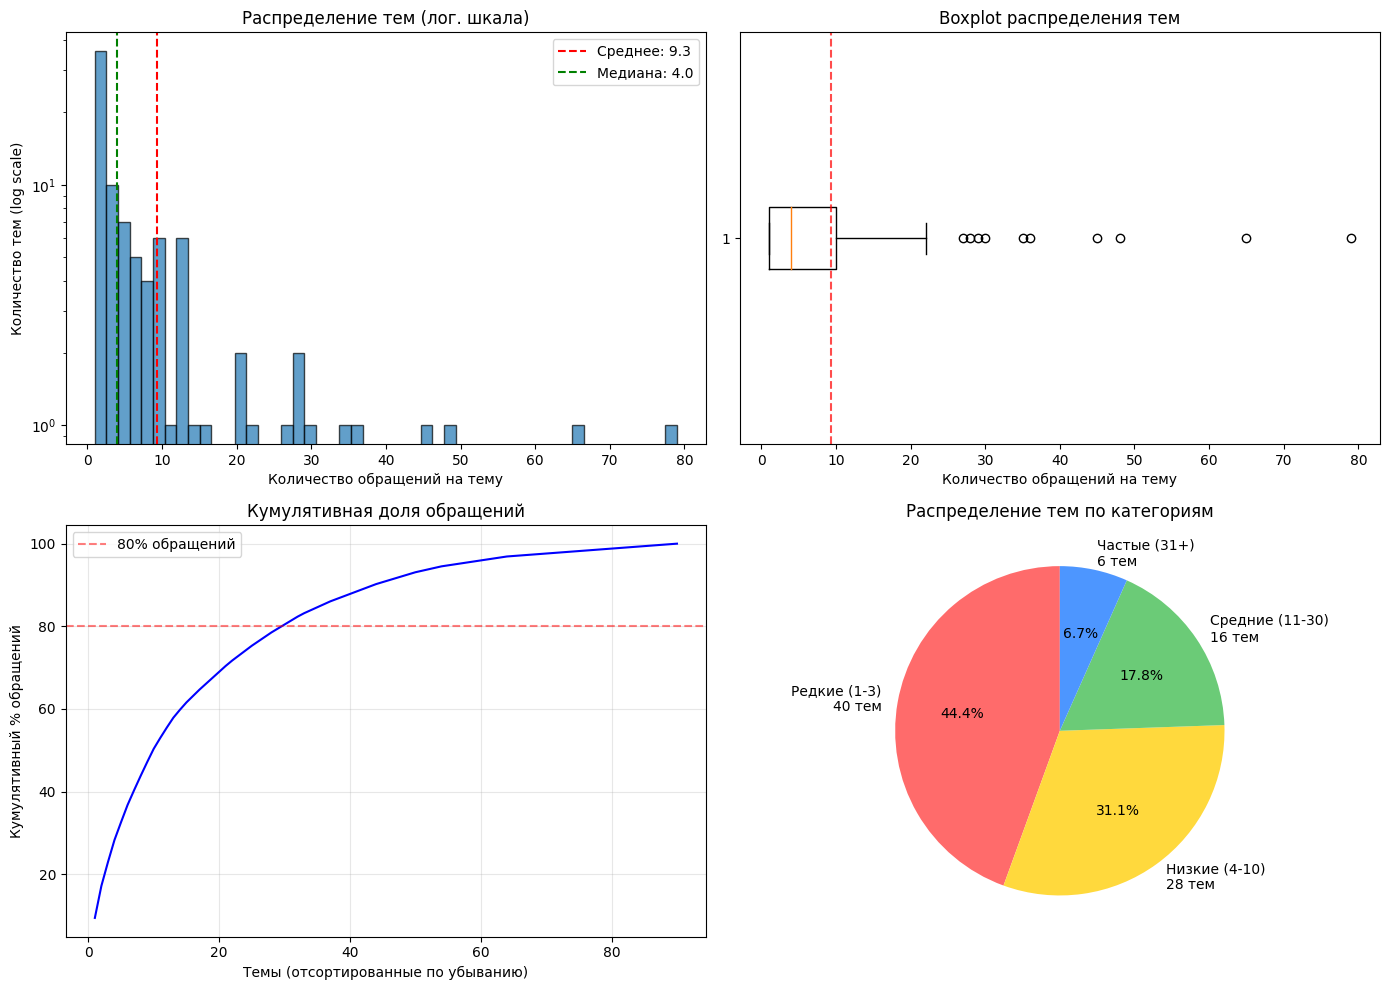

In [10]:
# наглядные графики

def categorize_themes(theme_counts):
    rare = theme_counts[theme_counts <= 3].count()      # 1-3 примера
    low = theme_counts[(theme_counts >= 4) & (theme_counts <= 10)].count()
    medium = theme_counts[(theme_counts >= 11) & (theme_counts <= 30)].count()
    high = theme_counts[theme_counts >= 31].count()
    
    print(f"🔴 Редкие (1-3 примера): {rare} тем ({rare/len(theme_counts)*100:.1f}%)")
    print(f"🟡 Низкие (4-10): {low} тем ({low/len(theme_counts)*100:.1f}%)")
    print(f"🟢 Средние (11-30): {medium} тем ({medium/len(theme_counts)*100:.1f}%)")
    print(f"🔵 Частые (31+): {high} тем ({high/len(theme_counts)*100:.1f}%)")
    
    return {'rare': rare, 'low': low, 'medium': medium, 'high': high}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Гистограмма с логарифмической шкалой
axes[0,0].hist(theme_counts, bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_yscale('log')
axes[0,0].set_xlabel('Количество обращений на тему')
axes[0,0].set_ylabel('Количество тем (log scale)')
axes[0,0].set_title('Распределение тем (лог. шкала)')
axes[0,0].axvline(theme_counts.mean(), color='red', linestyle='--', label=f'Среднее: {theme_counts.mean():.1f}')
axes[0,0].axvline(theme_counts.median(), color='green', linestyle='--', label=f'Медиана: {theme_counts.median():.1f}')
axes[0,0].legend()

# 2. Boxplot
axes[0,1].boxplot(theme_counts, vert=False)
axes[0,1].set_xlabel('Количество обращений на тему')
axes[0,1].set_title('Boxplot распределения тем')
axes[0,1].axvline(theme_counts.mean(), color='red', linestyle='--', alpha=0.7)

# 3. Кумулятивная доля
sorted_counts = theme_counts.sort_values(ascending=False)
cumulative = sorted_counts.cumsum() / sorted_counts.sum() * 100
axes[1,0].plot(range(1, len(cumulative)+1), cumulative, 'b-')
axes[1,0].set_xlabel('Темы (отсортированные по убыванию)')
axes[1,0].set_ylabel('Кумулятивный % обращений')
axes[1,0].set_title('Кумулятивная доля обращений')
axes[1,0].axhline(80, color='r', linestyle='--', alpha=0.5, label='80% обращений')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

# 4. Распределение по категориям
cat_counts = categorize_themes(theme_counts)
labels = [f'Редкие (1-3)\n{cat_counts["rare"]} тем', 
          f'Низкие (4-10)\n{cat_counts["low"]} тем',
          f'Средние (11-30)\n{cat_counts["medium"]} тем',
          f'Частые (31+)\n{cat_counts["high"]} тем']
sizes = [cat_counts['rare'], cat_counts['low'], cat_counts['medium'], cat_counts['high']]
colors = ['#ff6b6b', '#ffd93d', '#6bcb77', '#4d96ff']
axes[1,1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Распределение тем по категориям')

plt.tight_layout()
plt.show()

## Итог

Данные имеют сильный дисбаланс: 75% тем имеют ≤ 10 обращений.
Данных достаточно мало (всего 838 примеров для 90 тем).
Скорее всего, придётся добирать датасет.

# Baseline

Будем хранить эмебеддинги для всех известных примеров и для классификации нового искать ближайщий.

In [13]:
import os
from sklearn.neighbors import NearestNeighbors
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split

/Users/taraskvitko/PycharmProjects/nn_tool_rental/.venv2/lib/python3.8/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

## Деление на train и test

In [14]:
train, test = train_test_split(df, test_size=0.1, random_state=42)
print(f"Train: {len(train)}, Test: {len(test)}")

Train: 754, Test: 84


## Создание эмбеддингов

In [15]:
try:
    with open(os.path.join('..', 'config', 'HF_TOKEN.txt'), encoding='utf-8') as f:
        token = f.read()
        os.environ['HF_TOKEN'] = token
except FileNotFoundError:
    pass
model = SentenceTransformer('intfloat/multilingual-e5-small')
embeddings = model.encode(train['текст'].tolist())

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

## Обучение kNN

In [16]:
knn = NearestNeighbors(n_neighbors=1, metric='cosine')
knn.fit(embeddings)

NearestNeighbors(metric='cosine', n_neighbors=1)

## Тестирование

In [17]:
test_texts = test['текст'].tolist()
test_labels = test['тема'].tolist()

acc = 0
for test_text, test_label in zip(test_texts, test_labels):

    new_text_embedding = model.encode([test_text])
    distances, indices = knn.kneighbors(new_text_embedding)
    predicted_theme = train.iloc[indices[0][0]]['тема']
    if predicted_theme==test_label:
        sym = '🟢'
    else:
        sym = '🔴'
    print(test_text, '\n', sym, ' Предсказано: ', predicted_theme, ', На самом деле: ', test_label)
    acc += predicted_theme==test_label

print(f'\nТочность: {acc/len(test_texts)}')

 ,  есть невелиры ? 
 🔴  Предсказано:  штроборез , На самом деле:  нивелир оптический
!  торцовочник чтобы выполнить запил плинтуса под разные углы высотой 80 мм. сколько будет стоить  такого инструмента и условия аренды. 
 🟢  Предсказано:  торцовочная пила , На самом деле:  торцовочная пила
 ,   торцовочной пилы с диском для алюминия 
 🟢  Предсказано:  торцовочная пила , На самом деле:  торцовочная пила
, нужна дрель или шуруповерт(что дешевле)  и сверло на 6  на пару часов 
 🟢  Предсказано:  дрель-шуруповерт , На самом деле:  дрель-шуруповерт
  генератор или преобразователь для потребителя  1500вт 
 🟢  Предсказано:  генератор , На самом деле:  генератор
,  перфоратора  ? 
 🟢  Предсказано:  перфоратор , На самом деле:  перфоратор
, сколько будет стоить  строительного пылесоса с мешком для мусора? 
 🟢  Предсказано:  пылесос , На самом деле:  пылесос
. необходимо арендовать реноватор.  по наличию. еще , идет ли в комплекте оснастка? 
 🟢  Предсказано:  реноватор , На самом деле:  реноват

Baseline дает точность 0.67

## Итог

Реализован baseline, дающий точность 0.67

# Планы

Расширить датасет
- донабором данных
- аугментацией имеющихся данных
- автоматизировать получение новых примеров через LLM

Попробовать дообучить предобученные модели 
- cointegrated/rubert-tiny2 
- DeepPavlov/rubert-base-cased

## Метрики

Для оценки качества моделей планируется использовать F1-score.
Так что же почитал, что полезно будет смотреть на Per-class F1 (для поиска проблемных тем) и Confusion Matrix (есть ли ошибки на похожих темах).